In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv(r"C:\Users\bisha\OneDrive\Desktop\SalesForecasting_Bishal_Anand\data.csv")

In [4]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [8]:
#Convert order date and ship date in correct data type
df['Order Date']=pd.to_datetime(df['Order Date'],format="%d/%m/%Y")
df['Ship Date']=pd.to_datetime(df['Ship Date'],format="%d/%m/%Y")

In [9]:
# Season function
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

# Extract features for both columns
for col in ["Order Date", "Ship Date"]:
    prefix = col.replace(" ", "_")  # Order_Date, Ship_Date

    df[f"{prefix}_Year"] = df[col].dt.year
    df[f"{prefix}_Month"] = df[col].dt.month
    df[f"{prefix}_Week_Number"] = df[col].dt.isocalendar().week
    df[f"{prefix}_Day_of_Week"] = df[col].dt.dayofweek
    df[f"{prefix}_Quarter"] = df[col].dt.quarter
    df[f"{prefix}_Season"] = df[col].dt.month.apply(get_season)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Row ID                  9800 non-null   int64         
 1   Order ID                9800 non-null   object        
 2   Order Date              9800 non-null   datetime64[ns]
 3   Ship Date               9800 non-null   datetime64[ns]
 4   Ship Mode               9800 non-null   object        
 5   Customer ID             9800 non-null   object        
 6   Customer Name           9800 non-null   object        
 7   Segment                 9800 non-null   object        
 8   Country                 9800 non-null   object        
 9   City                    9800 non-null   object        
 10  State                   9800 non-null   object        
 11  Postal Code             9789 non-null   float64       
 12  Region                  9800 non-null   object  

In [14]:
# Checking for duplicate values
df.duplicated().sum()

0

Now data is clean. It do not contain any null values, duplicate values and no wrong data types.

In [29]:
#Extraction of year and month
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month

In [16]:
#Weekly sales
weekly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="W"))["Sales"]
      .sum()
      .reset_index()
)

print(weekly_sales.head())

  Order Date     Sales
0 2015-01-04   304.508
1 2015-01-11  4619.108
2 2015-01-18  4130.533
3 2015-01-25  3092.544
4 2015-02-01  2527.914


In [36]:
#Monthly sales
monthly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"]
      .sum()
)

print(monthly_sales.head())

C:\Users\bisha\AppData\Local\Temp\ipykernel_26424\3020764055.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"]


Order Date
2015-01-31    14205.707
2015-02-28     4519.892
2015-03-31    55205.797
2015-04-30    27906.855
2015-05-31    23644.303
Freq: ME, Name: Sales, dtype: float64


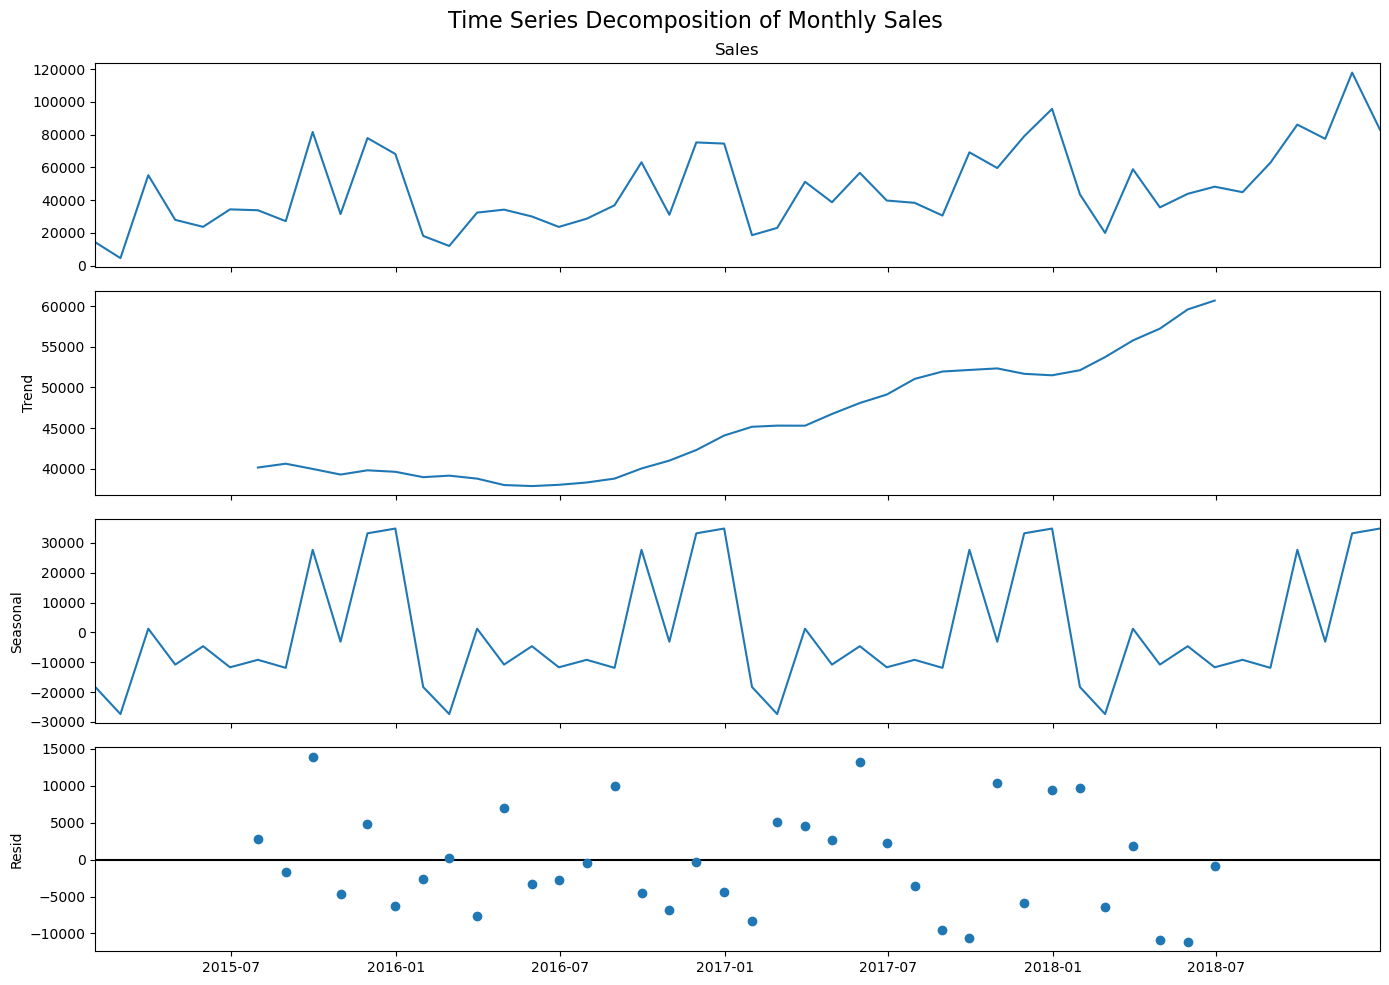

In [37]:
#Apply Time Series Decomposition
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    monthly_sales,
    model="additive",   # use "multiplicative" if seasonal fluctuations grow with sales
    period=12           # 12 months in a year
)

#Plot all four components
fig = decomposition.plot()
fig.set_size_inches(14, 10)
plt.suptitle("Time Series Decomposition of Monthly Sales", fontsize=16)
plt.tight_layout()
plt.show()

### Observations:-
- Observation 1 – Trend

The trend component shows the long-term movement in monthly sales. An upward trend indicates that overall sales have grown steadily over the four-year  period, while a downward trend would indicate declining sales.

- Observation 2 – Seasonality

The seasonal component reveals a repeating yearly pattern. If the same months consistently show positive seasonal values and the pattern repeats each year, then seasonality is strong. Otherwise, the seasonal effect is relatively weak.

- Observation 3 – Residual (Noise)

The residual component represents random fluctuations that cannot be explained by trend or seasonality. Large positive or negative spikes indicate months where unusual events such as promotions, holidays, or external factors affected sales.

- Observation 4 – Overall

Most of the variation in sales is explained by the combination of trend and seasonal effects, while the residual component captures irregular short-term variations.

## Checking for seasonality


# Some insights from data

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


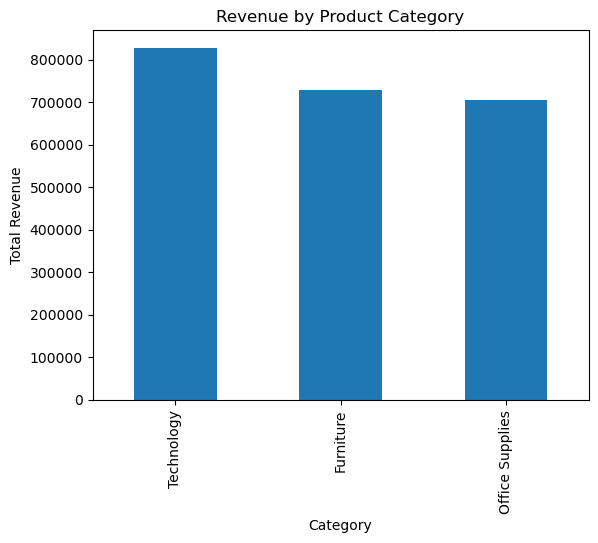

In [20]:
#Extracting high sales
category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print(category_sales)

#Visualisation
category_sales.plot(kind="bar")
plt.ylabel("Total Revenue")
plt.title("Revenue by Product Category")
plt.show()

Technology generated the highest total revenue with **827455.8730**, followed by Furniture and Office Supplies.

In [25]:
#Finding region who shows consistent growth
yearly_region_sales = (
    df.groupby(["Year", "Region"])["Sales"]
      .sum()
      .reset_index()
)

pivot = yearly_region_sales.pivot(
    index="Year",
    columns="Region",
    values="Sales"
)

print(pivot)

Region      Central        East        South         West
Year                                                     
2015    102920.5206  127652.819  103374.9055  145907.9630
2016    102425.1724  153225.183   70076.0825  133709.5675
2017    145673.8800  178511.538   93535.9035  182471.2285
2018    141627.3402  210129.186  122164.5675  248130.9255


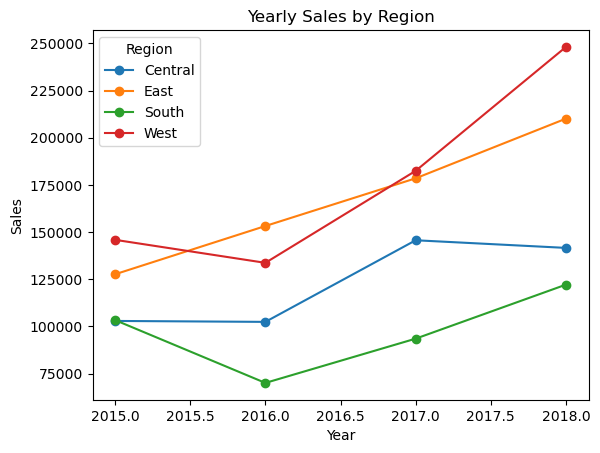

In [26]:
#Visualisation
pivot.plot(marker="o")
plt.ylabel("Sales")
plt.title("Yearly Sales by Region")
plt.show()

- The East region shows regular growth in sales during the intervals.
- West region sales has dropped from 2015 to 2016, but then it shows regular growth and even high sales in 2017 and 2018.
- While the south region has low sales in all 4 year.

## Finding Low gap between order date and ship date for different regions

In [27]:
#Finding shipping days
df["Shipping_Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

print(df["Shipping_Days"].mean())

#Average by region
shipping_region = (
    df.groupby("Region")["Shipping_Days"]
      .mean()
      .sort_values()
)

print(shipping_region)

3.9611224489795918
Region
East       3.910233
West       3.930255
South      3.961202
Central    4.065876
Name: Shipping_Days, dtype: float64


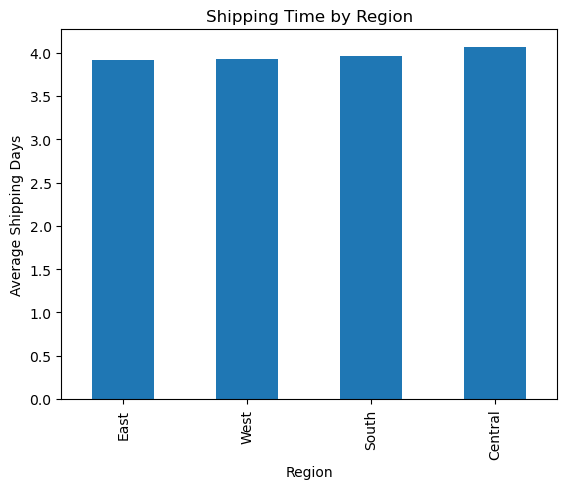

In [28]:
#Visualisation
shipping_region.plot(kind="bar")
plt.ylabel("Average Shipping Days")
plt.title("Shipping Time by Region")
plt.show()

The average shipping time is 4 days. The East region has the fastest delivery, whereas the Central region takes the longest. But there is small change, so we can infer that shipping days do not depend on the region.

### Checking seasonality

In [30]:
#Creation of monthly sales report
monthly_sales = (
    df.groupby(["Year", "Month"])["Sales"]
      .sum()
      .reset_index()
)

#pivot table
pivot = monthly_sales.pivot(
    index="Month",
    columns="Year",
    values="Sales"
)

print(pivot)

Year         2015        2016        2017         2018
Month                                                 
1      14205.7070  18066.9576  18542.4910   43476.4740
2       4519.8920  11951.4110  22978.8150   19920.9974
3      55205.7970  32339.3184  51165.0590   58863.4128
4      27906.8550  34154.4685  38679.7670   35541.9101
5      23644.3030  29959.5305  56656.9080   43825.9822
6      34322.9356  23599.3740  39724.4860   48190.7277
7      33781.5430  28608.2590  38320.7830   44825.1040
8      27117.5365  36818.3422  30542.2003   62837.8480
9      81623.5268  63133.6060  69193.3909   86152.8880
10     31453.3930  31011.7375  59583.0330   77448.1312
11     77907.6607  75249.3995  79066.4958  117938.1550
12     68167.0585  74543.6012  95739.1210   83030.3888


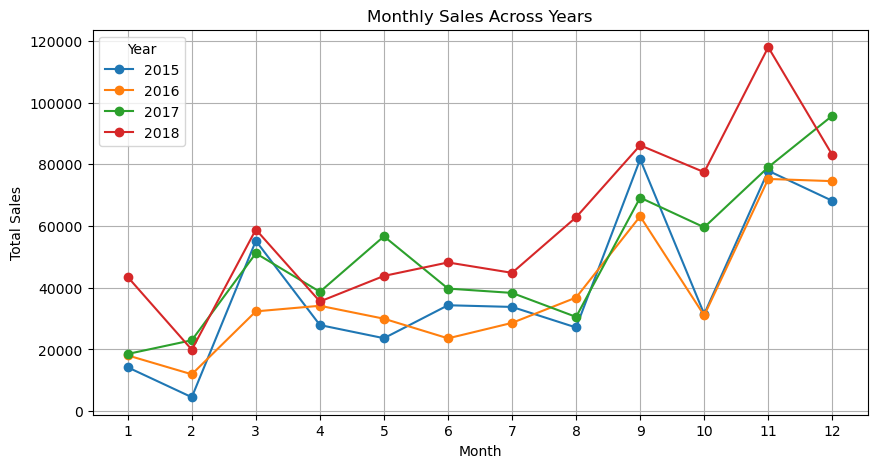

In [32]:
#Visualisation
pivot.plot(marker="o", figsize=(10, 5))
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.title("Monthly Sales Across Years")
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

We see spike at **March and Septembr**. It show seasonality there.

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 33 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Row ID                  9800 non-null   int64         
 1   Order ID                9800 non-null   object        
 2   Order Date              9800 non-null   datetime64[ns]
 3   Ship Date               9800 non-null   datetime64[ns]
 4   Ship Mode               9800 non-null   object        
 5   Customer ID             9800 non-null   object        
 6   Customer Name           9800 non-null   object        
 7   Segment                 9800 non-null   object        
 8   Country                 9800 non-null   object        
 9   City                    9800 non-null   object        
 10  State                   9800 non-null   object        
 11  Postal Code             9789 non-null   float64       
 12  Region                  9800 non-null   object  